# Model Fitting Deviation Test

This notebook tests the stability of the model fitting procedure by running it multiple times on the same data and analyzing the distribution of fitted parameters.

## Setup

In [1]:
# Imports
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from skopt.space import Real

from popy.simulation_tools import ForagingAgent
from popy.io_tools import load_behavior
from popy.behavior_data_tools import drop_time_fields, add_switch_info, convert_column_format
from popy.simulation_helpers import fit_simulate
from popy.config import PROJECT_PATH_LOCAL
import os

In [2]:
# Parameters
cv_splits = None
n_initial_points = 200
n_calls = 350
n_jobs = -1
verbose = False
n_simulation_trials = 100_000
make_plots = False

alpha_range = Real(0.01, 1, name='alpha')
beta_range = Real(.5, 80.0, name='beta')
V0_range = Real(0.05, .4, name='V0')

# Number of repetitions
n_repetitions = 20

# Monkey to test
monkey = 'ka'  # Change to 'po' if needed

In [3]:
# Load data
behav_monkey = load_behavior(monkey)
behav_monkey = drop_time_fields(behav_monkey)
behav_monkey = add_switch_info(behav_monkey)
behav_monkey = convert_column_format(behav_monkey, original='behavior')
behav_monkey = behav_monkey.dropna()

print(f"Loaded {len(behav_monkey)} trials for monkey {monkey}")

# Create environment
env = gym.make("zsombi/monkey-bandit-task-v0", n_arms=3, max_episode_steps=n_simulation_trials)

Loaded 23860 trials for monkey ka


## Run Multiple Fitting Iterations

Fit the Foraging model multiple times to assess variability in parameter estimates.

In [4]:
# Run fitting n_repetitions times
model_name = 'Foraging'
agent_class = ForagingAgent
fixed_params = {'reset_on_switch': True}
param_space = [alpha_range, beta_range, V0_range]

results_list = []

for i in range(n_repetitions):
    start_time = time.time()
    
    print(f"\n{'='*60}")
    print(f"Iteration {i+1}/{n_repetitions}")
    print(f"{'='*60}")
    
    # Fit the model
    results, behaviors_simulated = fit_simulate(
        agent_class, param_space, env, behav_monkey, fixed_params, 
        CV_splits=cv_splits, make_plots=make_plots, 
        n_calls=n_calls, n_initial_points=n_initial_points, n_jobs=n_jobs
    )
    
    # Store results
    result_dict = {
        'iteration': i + 1,
        'alpha': results['alpha'],
        'beta': results['beta'],
        'V0': results['V0'],
        'LPT_best': results['LPT_best'],
        'time_seconds': time.time() - start_time
    }
    
    results_list.append(result_dict)
    
    print(f"Fitted parameters: alpha={results['alpha']:.3f}, beta={results['beta']:.2f}, V0={results['V0']:.3f}")
    print(f"LPT: {results['LPT_best']:.3f}")
    print(f"Time: {result_dict['time_seconds']:.1f}s")

# Create DataFrame
deviation_results = pd.DataFrame(results_list)

# Save results
floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results')
deviation_results.to_csv(os.path.join(floc, f'deviation_test_{monkey}.csv'), index=False)

print(f"\n{'='*60}")
print(f"COMPLETED: {n_repetitions} fitting iterations")
print(f"Results saved to: {floc}/deviation_test_{monkey}.csv")
print(f"{'='*60}")


Iteration 1/20
Fitted parameters: alpha=0.394, beta=10.69, V0=0.128
LPT: 0.789
Time: 940.9s

Iteration 2/20
Fitted parameters: alpha=0.470, beta=10.75, V0=0.091
LPT: 0.788
Time: 946.6s

Iteration 3/20
Fitted parameters: alpha=0.420, beta=10.36, V0=0.111
LPT: 0.789
Time: 936.3s

Iteration 4/20
Fitted parameters: alpha=0.394, beta=10.94, V0=0.128
LPT: 0.788
Time: 970.8s

Iteration 5/20
Fitted parameters: alpha=0.432, beta=10.38, V0=0.096
LPT: 0.788
Time: 938.7s

Iteration 6/20
Fitted parameters: alpha=0.425, beta=11.49, V0=0.117
LPT: 0.788
Time: 970.7s

Iteration 7/20
Fitted parameters: alpha=0.442, beta=11.36, V0=0.116
LPT: 0.788
Time: 958.4s

Iteration 8/20
Fitted parameters: alpha=0.400, beta=10.35, V0=0.117
LPT: 0.789
Time: 959.4s

Iteration 9/20
Fitted parameters: alpha=0.433, beta=11.25, V0=0.117
LPT: 0.788
Time: 964.2s

Iteration 10/20
Fitted parameters: alpha=0.447, beta=11.51, V0=0.110
LPT: 0.788
Time: 973.8s

Iteration 11/20
Fitted parameters: alpha=0.423, beta=10.52, V0=0.110

In [5]:
# Display summary statistics
print("Summary Statistics:")
print("="*60)
print(deviation_results.describe())
print("\n")
print("Standard Deviations:")
for param in ['alpha', 'beta', 'V0', 'LPT_best']:
    print(f"  {param}: {deviation_results[param].std():.4f}")

deviation_results

Summary Statistics:
       iteration      alpha       beta         V0   LPT_best  time_seconds
count   20.00000  20.000000  20.000000  20.000000  20.000000     20.000000
mean    10.50000   0.417457  10.829240   0.116994   0.788349    976.105249
std      5.91608   0.021781   0.490919   0.012149   0.000261     25.453015
min      1.00000   0.382271  10.121483   0.091047   0.787853    936.259040
25%      5.75000   0.399401  10.387260   0.111013   0.788178    959.162666
50%     10.50000   0.418199  10.719723   0.116560   0.788428    974.069081
75%     15.25000   0.428601  11.203145   0.125739   0.788565    992.733679
max     20.00000   0.469673  11.790087   0.144346   0.788639   1021.365355


Standard Deviations:
  alpha: 0.0218
  beta: 0.4909
  V0: 0.0121
  LPT_best: 0.0003


,iteration,alpha,beta,V0,LPT_best,time_seconds
0,1,0.394350,10.689526,0.128155,0.788567,940.942988
1,2,0.469673,10.749921,0.091047,0.787943,946.553775
2,3,0.420452,10.358503,0.111326,0.788639,936.259040
3,4,0.394071,10.937472,0.128454,0.788451,970.807618
4,5,0.431618,10.377578,0.096361,0.788351,938.735141
5,6,0.424659,11.491771,0.117041,0.788182,970.711930
6,7,0.442487,11.360227,0.115549,0.787873,958.448716
7,8,0.399875,10.350254,0.117042,0.788548,959.400649
8,9,0.433177,11.249451,0.116845,0.788164,964.181196
9,10,0.447136,11.509480,0.110073,0.787853,973.815275


## Visualize Parameter Distributions

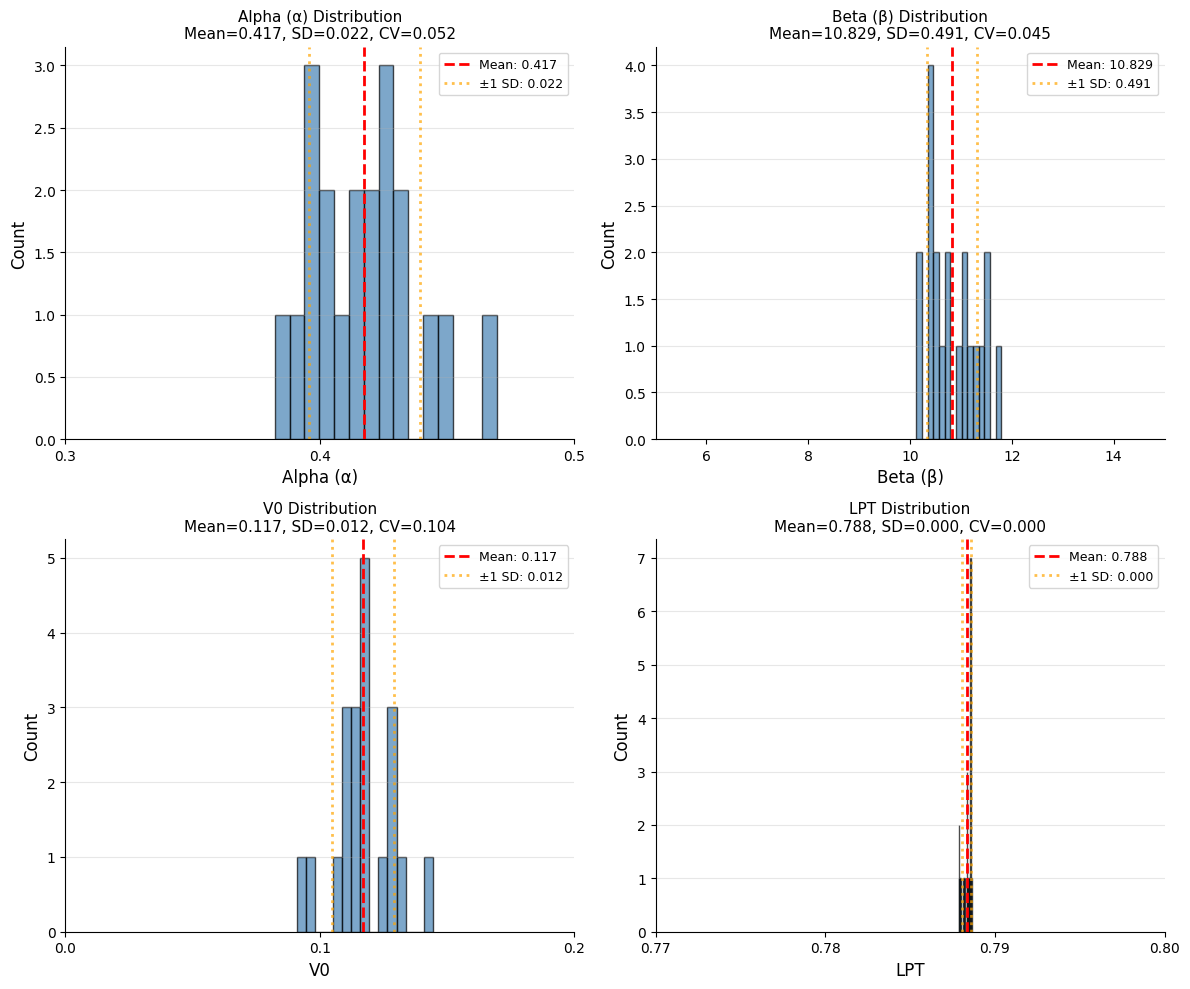


Coefficient of Variation (CV = SD/Mean):
  Alpha (α): 0.052 (5.2%)
  Beta (β): 0.045 (4.5%)
  V0: 0.104 (10.4%)
  LPT: 0.000 (0.0%)


In [11]:
# Plot distributions of fitted parameters
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

params = ['alpha', 'beta', 'V0', 'LPT_best']
param_labels = ['Alpha (α)', 'Beta (β)', 'V0', 'LPT']
param_limits = [(0.3, 0.5), (5, 15), (0, .2), (0.77, 0.80)]
param_ticks = [
    np.arange(0.3, 0.51, 0.1),  # alpha: 0.3, 0.4, 0.5
    None,  # beta: default ticks
    np.arange(0, 0.21, 0.1),  # V0: 0.0, 0.1, 0.2
    np.arange(0.77, 0.801, 0.01)  # LPT: 0.77, 0.78, 0.79, 0.80
]

for i, (param, label, xlim, xticks) in enumerate(zip(params, param_labels, param_limits, param_ticks)):
    ax = axes[i // 2, i % 2]
    
    # Histogram
    ax.hist(deviation_results[param], bins=15, edgecolor='black', alpha=0.7, color='steelblue')
    
    # Mean and std
    mean_val = deviation_results[param].mean()
    std_val = deviation_results[param].std()
    
    # Add vertical lines for mean and ±1 std
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
    ax.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=2, alpha=0.7)
    ax.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=2, alpha=0.7, label=f'±1 SD: {std_val:.3f}')
    
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'{label} Distribution\nMean={mean_val:.3f}, SD={std_val:.3f}, CV={std_val/mean_val:.3f}', fontsize=11)
    ax.set_xlim(xlim)
    if xticks is not None:
        ax.set_xticks(xticks)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figs/deviation_test_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Print coefficient of variation (CV) for each parameter
print("\nCoefficient of Variation (CV = SD/Mean):")
for param, label in zip(params, param_labels):
    cv = deviation_results[param].std() / deviation_results[param].mean()
    print(f"  {label}: {cv:.3f} ({cv*100:.1f}%)")

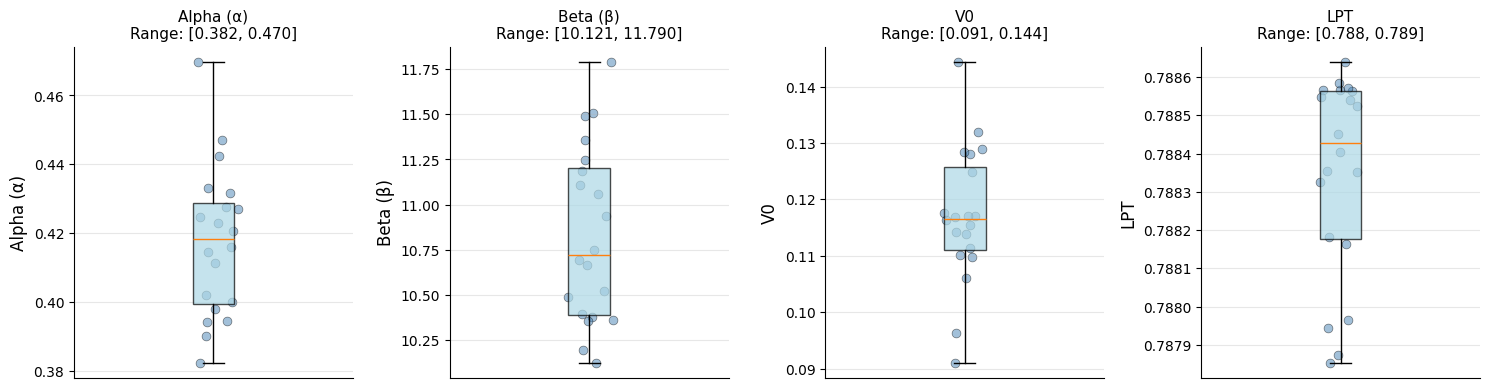

In [7]:
# Box plots for all parameters
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for i, (param, label) in enumerate(zip(params, param_labels)):
    ax = axes[i]
    
    # Box plot
    bp = ax.boxplot(deviation_results[param], vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][0].set_alpha(0.7)
    
    # Overlay individual points
    y = deviation_results[param]
    x = np.random.normal(1, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.5, color='steelblue', s=40, edgecolors='black', linewidth=0.5)
    
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'{label}\nRange: [{y.min():.3f}, {y.max():.3f}]', fontsize=11)
    ax.set_xticks([])
    ax.grid(alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figs/deviation_test_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

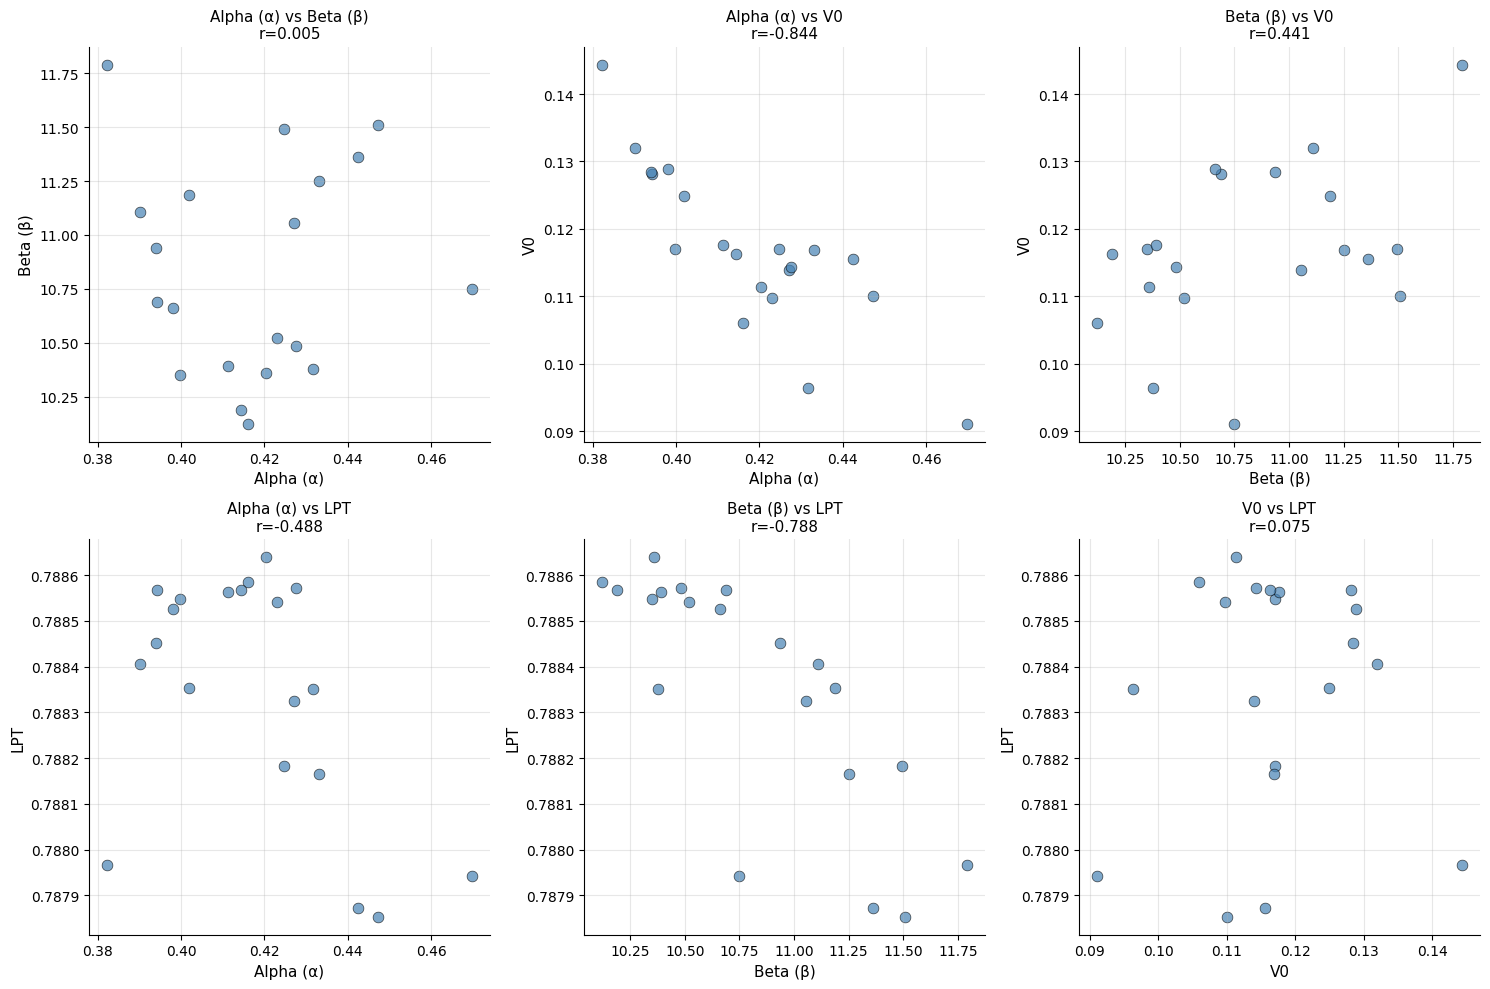


Parameter Correlations:
  Alpha (α) vs Beta (β): r=0.005
  Alpha (α) vs V0: r=-0.844
  Beta (β) vs V0: r=0.441
  Alpha (α) vs LPT: r=-0.488
  Beta (β) vs LPT: r=-0.788
  V0 vs LPT: r=0.075


In [8]:
# Pairwise scatter plots to check parameter correlations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

param_pairs = [
    ('alpha', 'beta', 'Alpha (α)', 'Beta (β)'),
    ('alpha', 'V0', 'Alpha (α)', 'V0'),
    ('beta', 'V0', 'Beta (β)', 'V0'),
    ('alpha', 'LPT_best', 'Alpha (α)', 'LPT'),
    ('beta', 'LPT_best', 'Beta (β)', 'LPT'),
    ('V0', 'LPT_best', 'V0', 'LPT')
]

for idx, (param1, param2, label1, label2) in enumerate(param_pairs):
    ax = axes[idx // 3, idx % 3]
    
    ax.scatter(deviation_results[param1], deviation_results[param2], 
               alpha=0.7, s=60, edgecolors='black', linewidth=0.5, color='steelblue')
    
    # Calculate correlation
    corr = deviation_results[param1].corr(deviation_results[param2])
    
    ax.set_xlabel(label1, fontsize=11)
    ax.set_ylabel(label2, fontsize=11)
    ax.set_title(f'{label1} vs {label2}\nr={corr:.3f}', fontsize=11)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figs/deviation_test_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nParameter Correlations:")
for param1, param2, label1, label2 in param_pairs:
    corr = deviation_results[param1].corr(deviation_results[param2])
    print(f"  {label1} vs {label2}: r={corr:.3f}")

## Summary

Key metrics to assess fitting stability:

1. **Coefficient of Variation (CV)**: Lower CV indicates more stable parameter estimates. CV < 0.1 (10%) is generally considered good.

2. **Parameter Ranges**: Tight ranges suggest the optimizer consistently finds similar solutions.

3. **Correlations**: Strong correlations between parameters may indicate trade-offs or non-identifiability.

4. **LPT Variability**: Low variability in LPT indicates consistent model fit quality across runs.

**Interpretation:**
- If CV is low (<10%) for all parameters, the fitting is stable and reliable.
- If CV is high (>20%), consider:
  - Increasing n_calls for more thorough optimization
  - Using different initial conditions
  - Checking for parameter identifiability issues (correlated parameters)
  - Possible multimodal likelihood surface